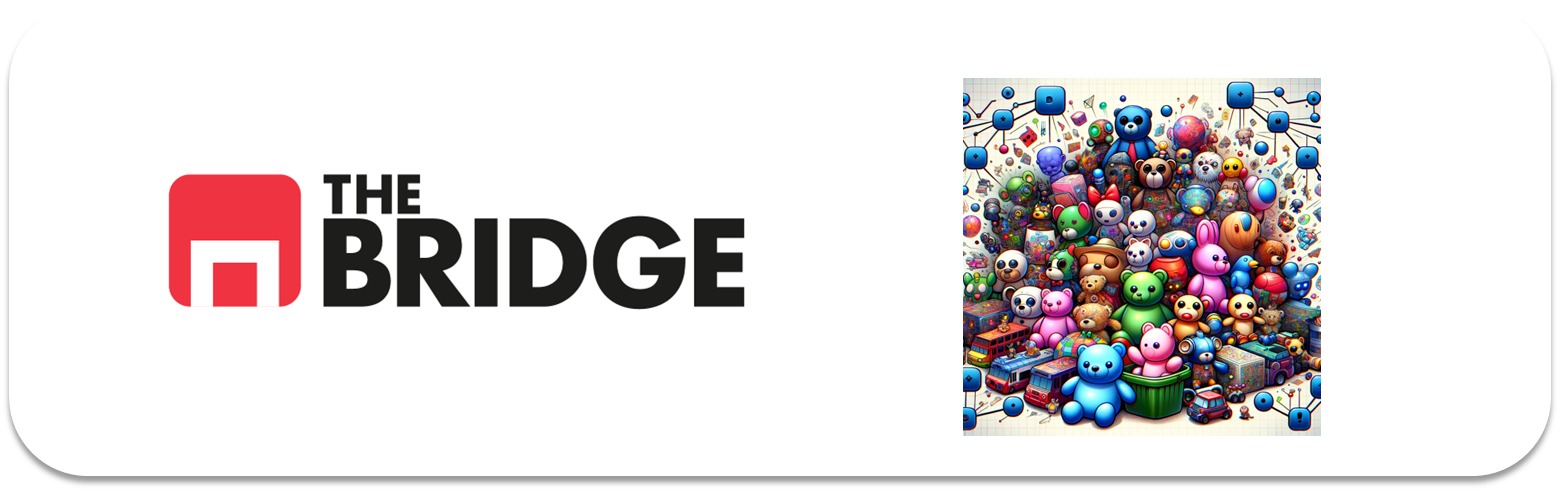

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad (para visualizar clusters en 2D si usas muchas features)
from sklearn.decomposition import PCA

# Modelos de clustering
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# Dendrograma (esto NO está en sklearn, viene de scipy)
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas de evaluación interna (sin target)
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Para buscar el eps óptimo en DBSCAN (método del codo con k-distancias)
from sklearn.neighbors import NearestNeighbors

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [7]:
df = pd.read_csv('./data/empowering_drinks.csv', sep='|')

In [8]:
df.head(5)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [10]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


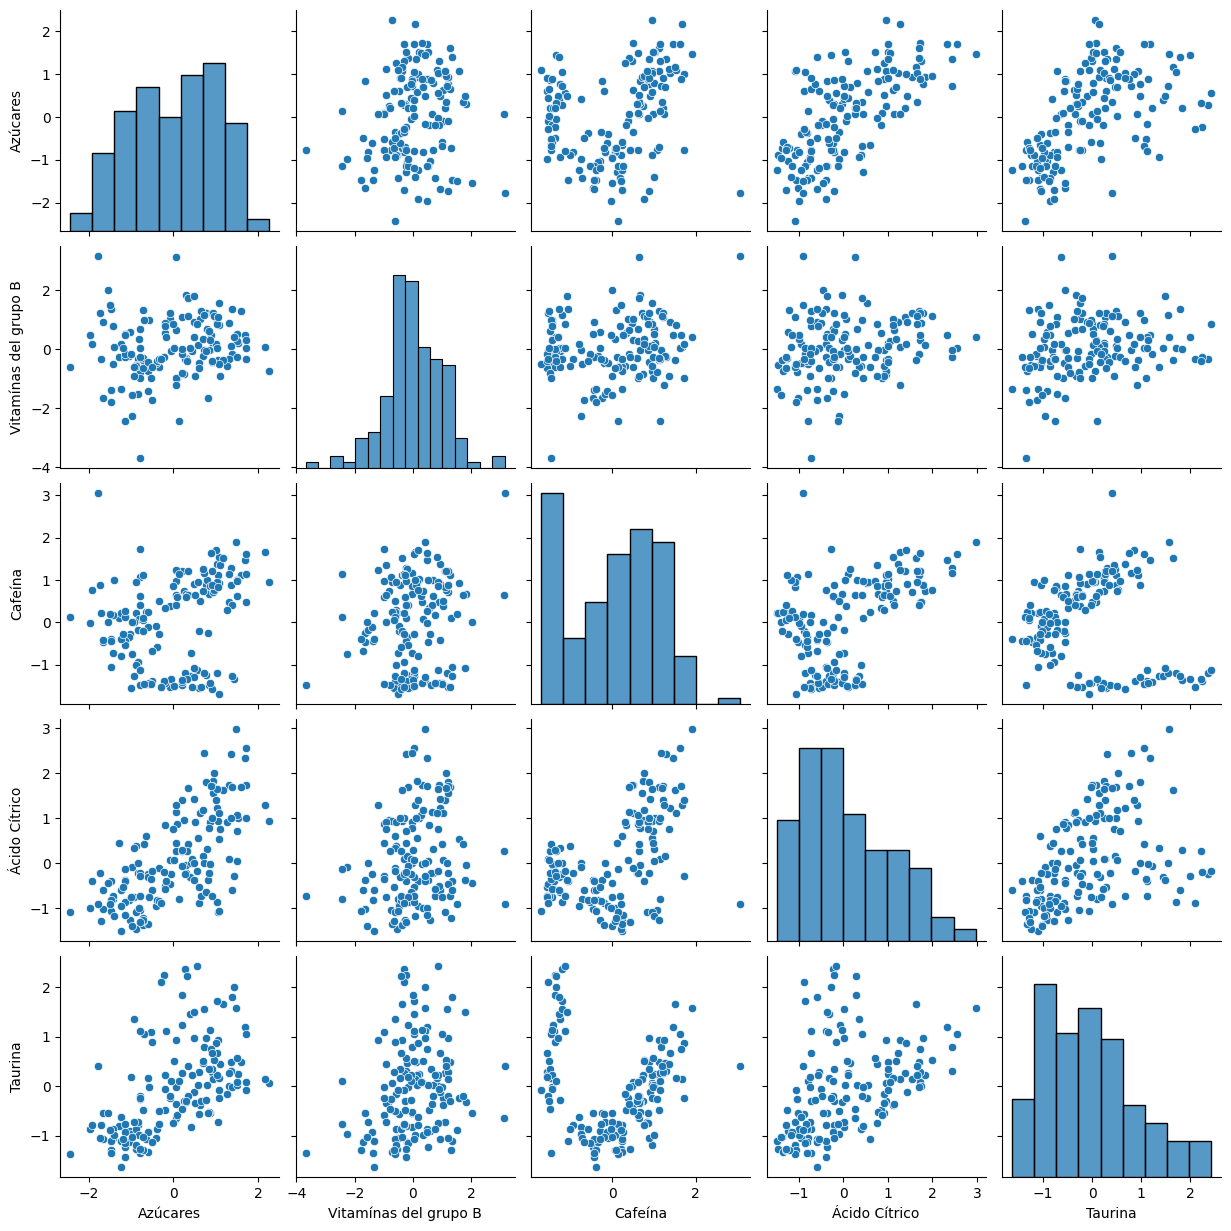

In [11]:
sns.pairplot(df)
plt.show()

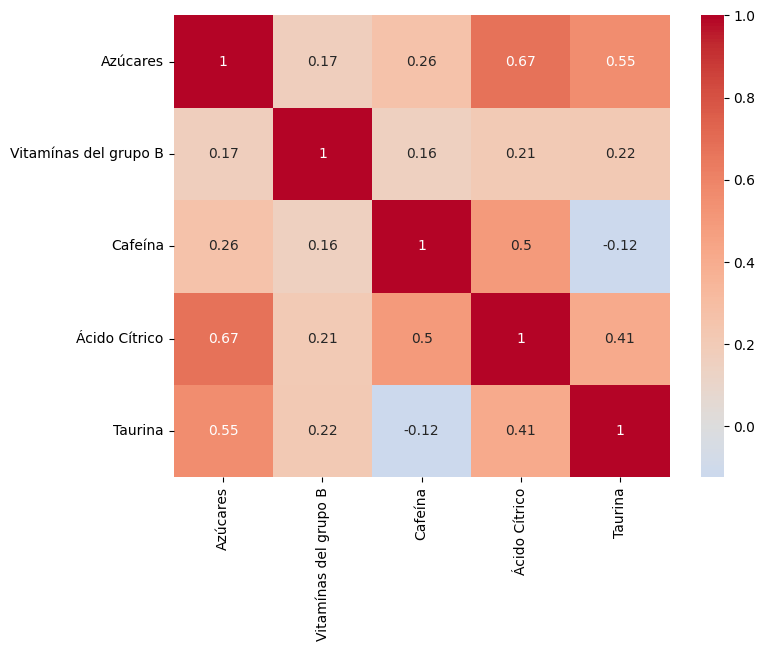

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

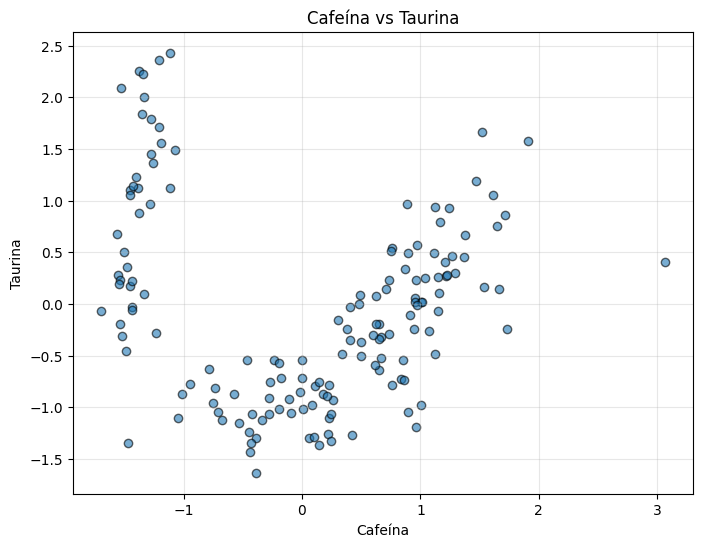

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(df['Cafeína'], df['Taurina'], alpha=0.6, edgecolor='k')
plt.xlabel('Cafeína')
plt.ylabel('Taurina')
plt.title('Cafeína vs Taurina')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
X = df[['Cafeína', 'Taurina']].values

In [15]:
dbscan = DBSCAN(eps=0.3,
                min_samples=4)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",4
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [16]:
labels = dbscan.labels_

In [17]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise}")

Clusters encontrados: 4
Puntos de ruido: 9


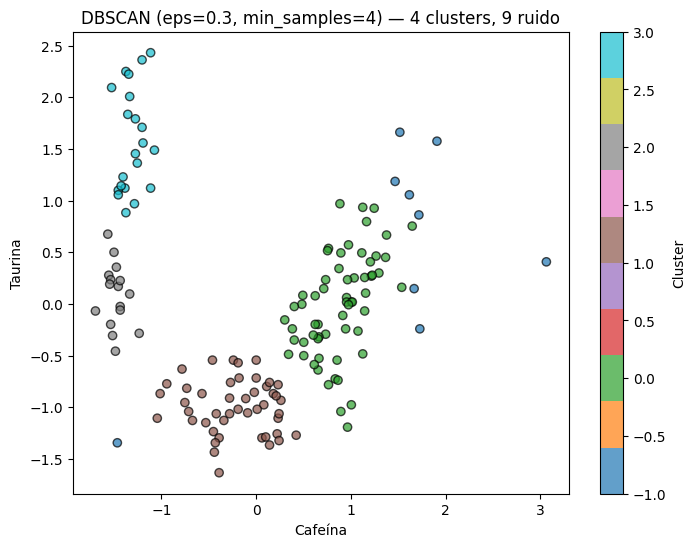

In [18]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', alpha=0.7, edgecolor='k')
plt.xlabel('Cafeína')
plt.ylabel('Taurina')
plt.title(f'DBSCAN (eps=0.3, min_samples=4) — {n_clusters} clusters, {n_noise} ruido')
plt.colorbar(scatter, label='Cluster')
plt.show()

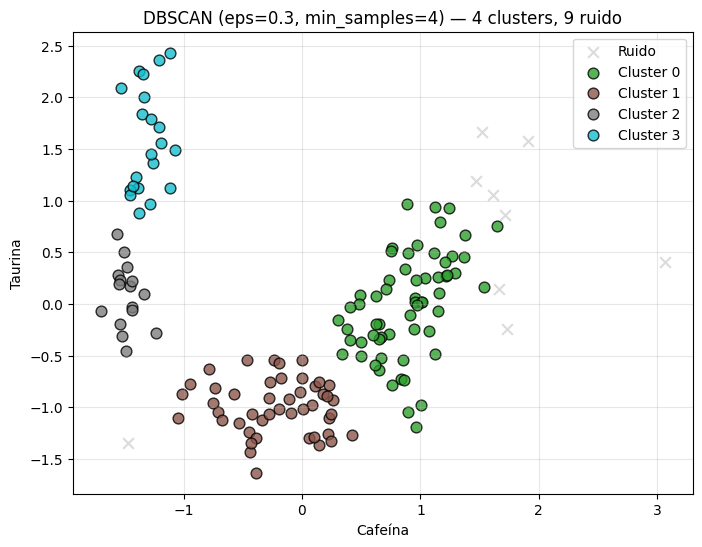

In [19]:
import matplotlib.patches as mpatches

unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8,6))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    if label == -1:
        # Ruido: lo pintamos en gris y con una X para diferenciarlo claramente
        plt.scatter(X[mask, 0], X[mask, 1], c='lightgray', marker='x',
                    s=60, label='Ruido', alpha=0.8)
    else:
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], edgecolor='k',
                    s=60, label=f'Cluster {label}', alpha=0.8)

plt.xlabel('Cafeína')
plt.ylabel('Taurina')
plt.title(f'DBSCAN (eps=0.3, min_samples=4) — {n_clusters} clusters, {n_noise} ruido')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Vamos a comparar otros epsilons por si acaso

for eps_test in [0.2, 0.25, 0.3, 0.35, 0.4]:
    db_test = DBSCAN(eps=eps_test, min_samples=4)
    db_test.fit(X)
    labels_test = db_test.labels_
    
    n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise_test = list(labels_test).count(-1)
    
    print(f"eps={eps_test}: {n_clust} clusters, {n_noise_test} ruido")

eps=0.2: 6 clusters, 38 ruido
eps=0.25: 4 clusters, 17 ruido
eps=0.3: 4 clusters, 9 ruido
eps=0.35: 2 clusters, 5 ruido
eps=0.4: 2 clusters, 5 ruido


** Conclusión: DBSCAN encontró una solución de 4 clusters consistente con las expectativas de los químicos, pero el resultado es sensible a eps fuera de una ventana relativamente estrecha (0.25-0.3), lo cual sugiere que los límites de densidad entre algunos clusters son difusos, no clusters perfectamente separados.

** Clustering jerárquico y el dendrograma

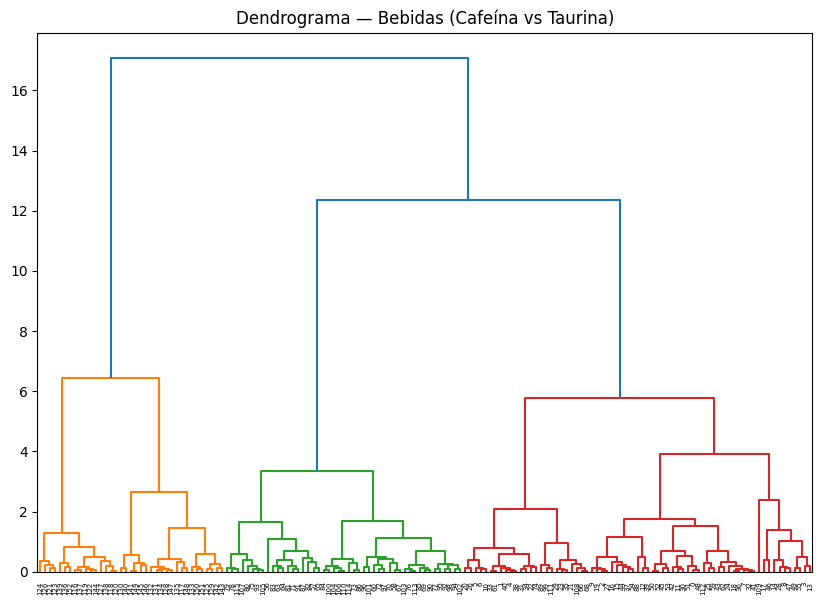

In [23]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
plt.title("Dendrograma — Bebidas (Cafeína vs Taurina)")

clusters = shc.linkage(X,
            method='ward',
            metric="euclidean")
shc.dendrogram(Z=clusters)
plt.show()

In [24]:
from scipy.cluster.hierarchy import fcluster

for k in [3, 4, 5]:
    labels_hier = fcluster(clusters, t=k, criterion='maxclust')
    score = silhouette_score(X, labels_hier)
    print(f"k={k}: silhouette = {score:.3f}")

k=3: silhouette = 0.518
k=4: silhouette = 0.523
k=5: silhouette = 0.441


Confirmamos que k4 es lo ideal. 4 clusters

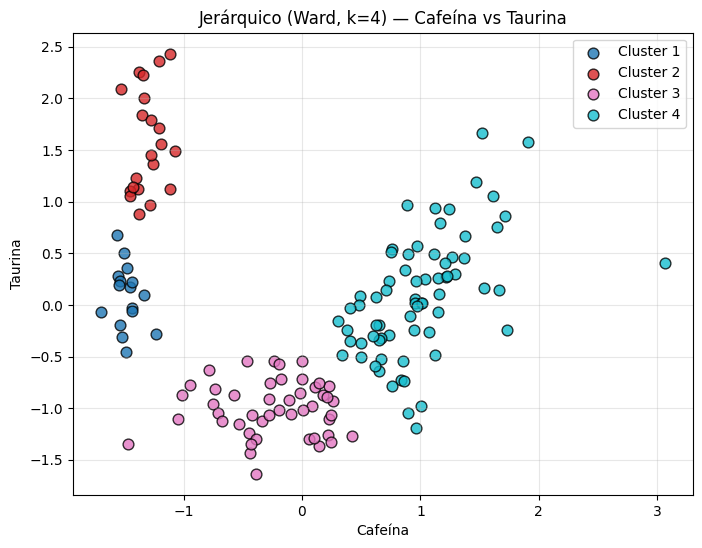

In [26]:
labels_hier_final = fcluster(clusters, t=4, criterion='maxclust')

unique_labels = sorted(set(labels_hier_final))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8,6))
for label, color in zip(unique_labels, colors):
    mask = labels_hier_final == label
    plt.scatter(X[mask, 0], X[mask, 1], c=[color], edgecolor='k',
                s=60, label=f'Cluster {label}', alpha=0.8)

plt.xlabel('Cafeína')
plt.ylabel('Taurina')
plt.title('Jerárquico (Ward, k=4) — Cafeína vs Taurina')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Aquí tienes la celda de discusión, redactada como una conclusión natural de todo lo que hemos ido viendo:
markdown## Discusión de resultados

### Comparación entre DBSCAN y Clustering Jerárquico

Los dos modelos coinciden en un punto clave: ambos encuentran **4 clusters** de forma independiente 
trabajando solo con Cafeína y Taurina (DBSCAN con eps=0.3 y min_samples=4; el jerárquico comparando 
silhouette score entre k=3, 4 y 5, donde k=4 dio el mejor resultado con 0.523). Que dos algoritmos tan 
distintos en su lógica interna lleguen al mismo número de grupos por caminos separados es una señal 
bastante sólida de que esa estructura de 4 segmentos es real en los datos, y no una casualidad de 
ajustar bien un hiperparámetro.

Donde sí difieren, y mucho, es en cómo tratan los puntos atípicos. DBSCAN construye los clusters a 
partir de zonas densas de puntos, y todo lo que queda fuera de esas zonas (porque no tiene suficientes 
vecinos cerca) lo marca explícitamente como ruido: en nuestro caso, 9 de las 153 mezclas (un 5.9%) no 
se asignaron a ningún cluster. El jerárquico, en cambio, no tiene ningún concepto de "esto no pertenece 
a nada": como va fusionando siempre los puntos o grupos más cercanos entre sí hasta formar un único 
árbol, al cortar ese árbol en 4 clusters cada punto termina dentro de algún grupo sí o sí, aunque esté 
bastante alejado del resto. Esto se nota claramente comparando los dos scatters: los puntos que DBSCAN 
dejaba fuera como ruido (por ejemplo la mezcla con Cafeína≈3.0, claramente aislada del resto) en el 
jerárquico terminan "adoptados" por el cluster más cercano.

Para el caso de uso de los químicos, esto tiene una lectura práctica: si lo que interesa es detectar 
mezclas raras o experimentales que merece la pena revisar antes de fabricar un prototipo, DBSCAN da 
esa información de forma directa. Si en cambio interesa tener todas las mezclas clasificadas en alguna 
de las 3-5 familias sin dejar ninguna fuera, el jerárquico encaja mejor con ese objetivo.

### ¿Por qué esta comparación es meramente especulativa?

Porque no contamos con ningún target real contra el que validar los clusters. No se han hecho test de 
sabor ni de capacidad antifatiga/antisueño con usuarios, así que no existe una "verdad" objetiva que nos 
diga si una mezcla del Cluster 1 realmente sabe distinto o tiene un efecto distinto a una del Cluster 3. 
Las únicas métricas que tenemos (silhouette score, cantidad de ruido) miden si los clusters están bien 
separados y son compactos matemáticamente, pero no si esa separación significa algo relevante en sabor 
o en efecto real del producto. La interpretación de qué representa cada segmento (¿es la familia 
"alta en cafeína", la familia "suave", etc.?) solo la pueden confirmar los químicos probando físicamente 
representantes de cada cluster.

### Relación entre segmentos

Aquí el dendrograma aporta algo que DBSCAN no puede dar de forma nativa: una jerarquía de similitud 
entre los propios clusters. Mirando la estructura del árbol, las ramas naranja y verde se fusionan entre 
sí a una altura bastante más baja (~12.3) que la altura a la que se une la rama roja al resto (~17). 
Esto indica que el segmento "rojo" es el más distinto de los tres grandes grupos, mientras que naranja 
y verde son relativamente más parecidos entre sí (aunque siguen estando bastante separados si los 
comparamos con las distancias internas de cada grupo, que rondan 3-6). Esta es otra ventaja de haber 
incluido el jerárquico además de DBSCAN: no solo te dice cuántos grupos hay, sino también qué tan 
cerca o lejos están unos de otros.

### Consideración final

Solo trabajamos con 2 de las 5 features originales (Cafeína y Taurina), elegidas tras visualizar todas 
las combinaciones dos a dos y detectar que era el par con la estructura más clara (forma de medialuna). 
Sin embargo, el heatmap de correlaciones mostró que Azúcares y Ácido Cítrico también covarían de forma 
moderada con el resto, así que una posible siguiente iteración sería repetir el proceso incluyendo esas 
variables (sin necesidad de PCA, visualizando por pares como hicimos aquí) para comprobar si aparece 
alguna subdivisión adicional dentro de los 4 segmentos ya encontrados.


### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.